# ARC-AGI-3 Duck: Qwen 3.8 visible-memory candidate

This candidate changes exactly one capability from the current public Tufa Duck visible-memory notebook: it uses the offline Apache-2.0 Qwen3.8-27B FP8 dataset `saltb0x/qwen3-8-27b-fp8`. The existing visible world-model contract is retained.

The attached model and the Qwen3.6 baseline both declare the `qwen3_5` conditional-generation architecture, so the released vLLM command, Qwen tool parser, reasoning parser, context budget, sampling settings, and multimodal input remain unchanged. The startup code asserts every intended substitution before the server launches.

Use RTX Pro 6000 with Internet disabled. A normal Save & Run evaluates the public games; a competition rerun uses the gateway-provided hidden games.

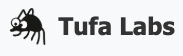

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [1]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

taaf.kaggle: TRUE_SUBMISSION=False


## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [2]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

0

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [3]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "saltb0x/qwen3-8-27b-fp8"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

taaf.kaggle: source bundle = /kaggle/input/datasets/jeroencottaar/taaf-kaggle-source-share
taaf.kaggle: input paths = {"driessmit1/arc3-vllm-h100-wheelhouse-v3": "/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3", "jeroencottaar/taaf-kaggle-source-share": "/kaggle/input/datasets/jeroencottaar/taaf-kaggle-source-share", "saltb0x/qwen3-8-27b-fp8": "/kaggle/input/datasets/saltb0x/qwen3-8-27b-fp8"}


## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [4]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
QWEN38_DATASET = "saltb0x/qwen3-8-27b-fp8"
QWEN38_OWNER = "saltb0x"
QWEN38_SLUG = "qwen3-8-27b-fp8"
QWEN38_SERVED_MODEL = "saltb0x/Qwen3.8-27B-FP8"


def _qwen38_setup_command(command: str) -> str:
    replacements = {
        "MODEL_OWNER = 'driessmit1'": f"MODEL_OWNER = '{QWEN38_OWNER}'",
        "MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'": f"MODEL_SLUG = '{QWEN38_SLUG}'",
        "SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'": f"SERVED_MODEL_NAME = '{QWEN38_SERVED_MODEL}'",
    }
    for old, new in replacements.items():
        if old not in command:
            raise RuntimeError(f"Qwen 3.8 setup preflight missing expected text: {old}")
        command = command.replace(old, new, 1)
    if "qwen3_coder" not in command or "--reasoning-parser" not in command:
        raise RuntimeError("Qwen 3.8 setup preflight lost the released Qwen tool/reasoning parsers.")
    return command


if QWEN38_DATASET not in DATASET_SOURCES:
    raise RuntimeError("Qwen 3.8 dataset is not attached in DATASET_SOURCES.")
if not Path(kaggle_input_paths[QWEN38_DATASET]).exists():
    raise FileNotFoundError(f"Qwen 3.8 dataset mount is missing: {kaggle_input_paths[QWEN38_DATASET]}")

env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    command = _qwen38_setup_command(command)
    print(f"taaf.kaggle: Qwen 3.8 setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

taaf.kaggle: wrote /usr/local/lib/python3.12/dist-packages/taaf_kaggle_sources.pth (3 source roots)
taaf.kaggle: Qwen 3.8 setup command: "$PYTHON" - <<'PYSETUP'
import json
import os
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

WHEELHOUSE_OWNER = 'driessmit1'
WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'
MODEL_OWNER = 'saltb0x'
MODEL_SLUG = 'qwen3-8-27b-fp8'
SERVED_MODEL_NAME = 'saltb0x/Qwen3.8-27B-FP8'
VLLM_HOST = '127.0.0.1'
VLLM_PORT = 1234
VLLM_BASE_URL = f'http://{VLLM_HOST}:{VLLM_PORT}/v1'
VLLM_MAX_MODEL_LEN = 65536
ANALYZER_CONTEXT_WINDOW = 32768
VLLM_TENSOR_PARALLEL_SIZE = 1
WORKING_DIR = Path(os.environ['TAAF_KAGGLE_WORKING_DIR'])
SITE_PACKAGES = WORKING_DIR / 'vllm-site-packages'
VLLM_SERVER_LOG = WORKING_DIR / 'vllm-openai-server.log'
VLLM_SERVER_PID = WORKING_DIR / 'vllm-openai-server.pid'
INSTALL_STAMP = SITE_PACKAGES / f'.{WHEELHOUSE_SLUG}'
STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\n'

GPU_NAME_

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [5]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Require visible world-model updates

Install one narrow prompt overlay after Tufa has loaded. Tufa already requires
the model to revise its world model before acting, but it also describes
assistant text before a tool call as optional. With a reasoning parser, the
model can therefore place an update in hidden reasoning where Tufa's compact
persistent-memory parser cannot consume it.

This overlay resolves only that channel ambiguity. Before every Python tool
call, the model must put its complete revised world model in **visible assistant
text**, using Tufa's existing labeled fields. Hidden reasoning may still be
used for thinking, but it is not treated as a memory update. The overlay does
not copy hidden reasoning, parse it as memory, or create a second memory store.

The attached Tufa bundle and its model settings, tools, images, history,
timeouts, concurrency, deadlines, benchmark flow, and scoring remain
unchanged. A preflight verifies the installed contract before evaluation.


In [6]:
# Prompt-only visible world-model update contract.
from inference.agent import tool_agent as _visible_updates_tool_agent

_VISIBLE_UPDATES_SENTINEL = "TUFA VISIBLE WORLD-MODEL UPDATE CONTRACT"
_VISIBLE_UPDATES_CONTRACT = """
TUFA VISIBLE WORLD-MODEL UPDATE CONTRACT (MANDATORY):
Before every `python` tool call, write the complete revised world model in visible assistant response text, then make the tool call in the same assistant response. Use a non-empty `World model:` line and include `Goal model:`, `Action model:`, `Recent findings:`, `Open questions:`, `Plan:`, and `Cross-level notes:` whenever they contain useful information. This visible text is the persistent-memory update Tufa will carry forward.

Do not leave the world-model update only in hidden thinking or reasoning. Hidden reasoning may be used for private deliberation, but Tufa does not treat it as persistent memory. The earlier statement that begins `If you include assistant text before a tool call` does not make this update optional: visible world-model text is required before every `python` tool call.
""".strip()


if not getattr(_visible_updates_tool_agent.ToolAgent, "_visible_updates_contract_installed", False):
    _visible_updates_original_init = _visible_updates_tool_agent.ToolAgent.__init__

    def _visible_updates_init(self, *args, **kwargs):
        _visible_updates_original_init(self, *args, **kwargs)
        if _VISIBLE_UPDATES_SENTINEL not in self._system_prompt:
            self._system_prompt = (
                self._system_prompt.rstrip()
                + "\n\n"
                + _VISIBLE_UPDATES_CONTRACT
            )

    _visible_updates_tool_agent.ToolAgent.__init__ = _visible_updates_init
    _visible_updates_tool_agent.ToolAgent._visible_updates_contract_installed = True


_visible_updates_probe = _visible_updates_tool_agent.ToolAgent(model=getattr(bm.solver, "model", "local"))
_visible_updates_prompt = _visible_updates_probe._system_prompt
_visible_updates_required = (
    _VISIBLE_UPDATES_SENTINEL,
    "visible assistant response text",
    "Do not leave the world-model update only in hidden thinking or reasoning",
    "visible world-model text is required before every `python` tool call",
)
_visible_updates_missing = [
    marker for marker in _visible_updates_required if marker not in _visible_updates_prompt
]
if _visible_updates_missing:
    raise RuntimeError(
        "Visible world-model update contract failed preflight: "
        + repr(_visible_updates_missing)
    )

_visible_updates_parser_sample = _visible_updates_tool_agent._extract_scientist_note(
    "World model: visible test update\nPlan: visible test plan"
)
if not any(str(value or "").strip() for value in _visible_updates_parser_sample.values()):
    raise RuntimeError("Tufa's parser rejected the visible-update preflight sample.")

_visible_updates_audit = {
    "contract": "visible world-model updates",
    "installation": "runtime ToolAgent initialization wrapper",
    "system_prompt_appended": True,
    "visible_assistant_text_required_before_python": True,
    "hidden_reasoning_used_as_persistent_memory": False,
    "hidden_reasoning_copied_to_visible_content": False,
    "request_or_response_transport_modified": False,
    "tufa_parser_accepts_visible_sample": True,
    "analyzer_timeout": getattr(bm.solver, "analyzer_timeout", None),
    "concurrency": getattr(bm.solver, "concurrency", None),
    "save_request_logs": getattr(bm.solver, "save_request_logs", None),
}
(WORKING_DIR / "visible_updates_prompt_contract.json").write_text(
    json.dumps(_visible_updates_audit, indent=2) + "\n",
    encoding="utf-8",
)
print("Visible world-model update contract active:", _visible_updates_audit, flush=True)


Visible world-model update contract active: {'contract': 'visible world-model updates', 'installation': 'runtime ToolAgent initialization wrapper', 'system_prompt_appended': True, 'visible_assistant_text_required_before_python': True, 'hidden_reasoning_used_as_persistent_memory': False, 'hidden_reasoning_copied_to_visible_content': False, 'request_or_response_transport_modified': False, 'tufa_parser_accepts_visible_sample': True, 'analyzer_timeout': 900.0, 'concurrency': 28, 'save_request_logs': False}


## 7. Run Tufa Duck (Visible Updates)

Run the standard Tufa benchmark with the visible-update prompt contract. In a
real competition rerun, the notebook waits for the Kaggle gateway and plays the
live competition Arcade. An ordinary Save & Run uses the bundled offline games.


In [7]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

benchmark.label : duck-harness-kaggle
benchmark.solver: HarnessSolver(label='duck-harness', runtime_environment=None, job_dir=None, soft_end_time=None, minimal_diagnostics=False, model='local', analyzer_timeout=900.0, max_actions_per_game=None, max_runtime_s_per_game=7920.0, concurrency=28, save_request_logs=False, start_local_server=False, local_server_config='', local_server_api_key_file='', local_server_repo_dir='/Users/jeroencottaar/code/ARC3-Inference', local_server_port=None, local_server_tensor_parallel_size=None, local_server_count=1, cancel_drain_timeout_s=120.0)
benchmark.passes: 1
benchmark.games : 25
git status:
  ARC3-Inference                   aa69123     DIRTY  add-kaggle-share-flag     Add flag to use shareable notebook
  tufa-arc-agi-framework           fe9f7c4     clean  submission-share-mode-bugfix  Fix dataset mapping, spell Isaiah's name properly
  re-arc-3                         57e46d619d  pinned  master                    (non-editable)
benchmark: regenerated 

analyzer request failed at action 5: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 2.02s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-08-15 20:57:31
ended:     in progress
mean score:    0.76
median score:  0.00
total actions: 239
total tokens:  379737
generated tokens/sec: 315.07 (job wallclock)
total wallclock: 22772.6s

per-game (mean across passes):
  ar25-0c556536: score=2.78, levels=1.0/8, actions=18, tokens=10434
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=3, tokens=15653
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=3, tokens=10312
  cn04-2fe56bfb: score=0.00, levels=0.0/6, actions=2, tokens=7141
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=5, tokens=14972
  ft09-0d8bbf25: score=0.00, levels=0.0/6, actions=12, tokens=18751
  g50t-5849a774: score=0.00, levels=0.0/7, actions=13, tokens=18674
  ka59-38d34dbb: score=0.00, levels=0.0/7, actions=5, tokens=17337
  lf52-271a04aa: score=0.00, levels=0.0/10, actions=4, t

analyzer request failed at action 14: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 1.82s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-08-15 20:57:31
ended:     in progress
mean score:    1.79
median score:  0.00
total actions: 628
total tokens:  904171
generated tokens/sec: 300.28 (job wallclock)
total wallclock: 62199.1s

per-game (mean across passes):
  ar25-0c556536: score=2.78, levels=1.0/8, actions=26, tokens=37106
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=8, tokens=27272
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=15, tokens=40953
  cn04-2fe56bfb: score=0.00, levels=0.0/6, actions=19, tokens=31523
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=11, tokens=35319
  ft09-0d8bbf25: score=14.29, levels=2.0/6, actions=32, tokens=33202
  g50t-5849a774: score=0.00, levels=0.0/7, actions=13, tokens=18674
  ka59-38d34dbb: score=0.00, levels=0.0/7, actions=15, tokens=36229
  lf52-271a04aa: score=1.82, levels=1.0/10, action

...

[finished] dc22-fdcac232 state=gave_up level=0/6 score=0.00 actions=30 tokens=94592 per-level=30/59,0/102,0/67,0/98,0/324,0/578 note="tokens=94592"
[finished] cn04-2fe56bfb state=gave_up level=0/6 score=0.00 actions=26 tokens=111444 per-level=26/29,0/54,0/85,0/300,0/208,0/113 note="tokens=111444"
[finished] sk48-d8078629 state=gave_up level=0/8 score=0.00 actions=54 tokens=95878 per-level=54/61,0/177,0/101,0/103,0/230,0/181,0/125,0/92 note="tokens=111352"
[finished] lf52-271a04aa state=gave_up level=1/10 score=1.82 actions=24 tokens=111071 per-level=11/32,13/81,0/60,0/71,0/205,0/148,0/244,0/109,0/164,0/225 note="tokens=111071"
[finished] bp35-0a0ad940 state=gave_up level=0/9 score=0.00 actions=14 tokens=110921 per-level=14/21,0/48,0/44,0/38,0/33,0/87,0/86,0/131,0/163 note="tokens=110921"
[finished] wa30-ee6fef47 state=gave_up level=0/9 score=0.00 actions=87 tokens=85989 per-level=87/71,0/119,0/183,0/98,0/368,0/68,0/79,0/442,0/415 note="tokens=85989"
[finished] r11l-495a7899 state=gave_

analyzer request failed at action 49: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=230.1462978139989)


[finished] cd82-fb555c5d state=gave_up level=1/6 score=4.76 actions=48 tokens=94055 per-level=37/55,11/8,0/41,0/21,0/23,0/23 note="tokens=109113"


analyzer request failed at action 82: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=47.889113257000645)


[finished] lp85-305b61c3 state=gave_up level=4/8 score=22.15 actions=81 tokens=111040 per-level=8/17,9/38,46/31,18/16,0/41,0/60,0/26,0/159 note="tokens=111491"
benchmark: regenerated diagnostics in /kaggle/working in 4.28s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-08-15 20:57:31
ended:     2026-08-15 23:10:11
duration:  2h 12m 39s
mean score:    4.22
median score:  1.82
total actions: 1475
total tokens:  2289868
generated tokens/sec: 287.69 (job wallclock)
total wallclock: 198111.8s

per-game (mean across passes):
  ar25-0c556536: score=8.33, levels=2.0/8, actions=47, tokens=82565
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=14, tokens=110921
  cd82-fb555c5d: score=4.76, levels=1.0/6, actions=48, tokens=94055
  cn04-2fe56bfb: score=0.00, levels=0.0/6, actions=26, tokens=111444
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=30, tokens=94592
  ft09-0d8bbf25: score=28.57, levels=3.0/6, actions=67, tok

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



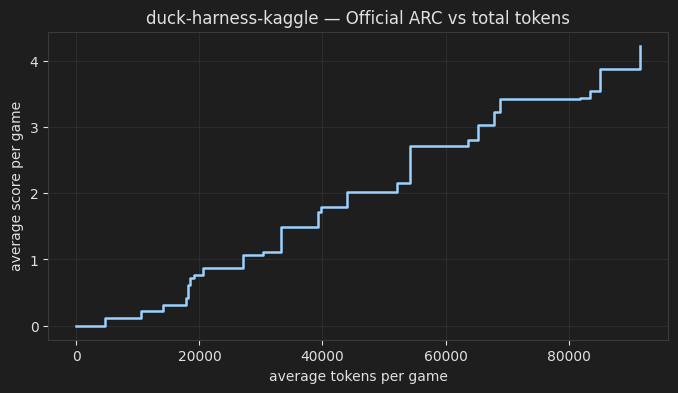
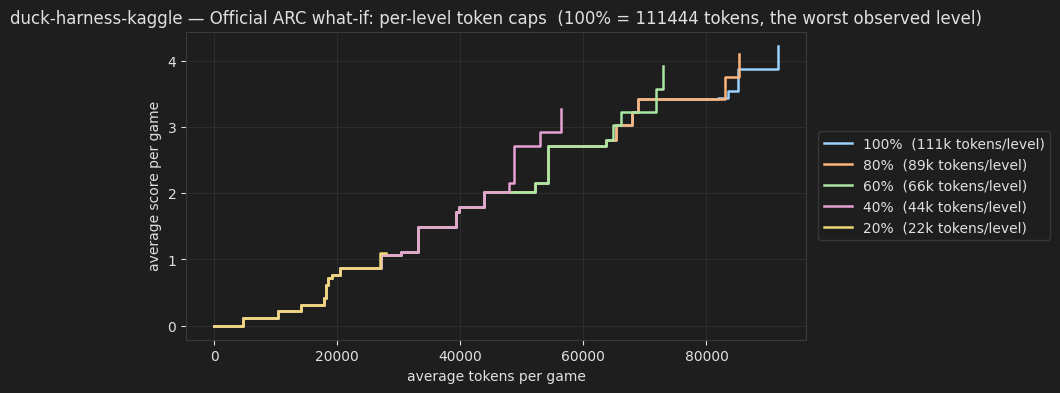
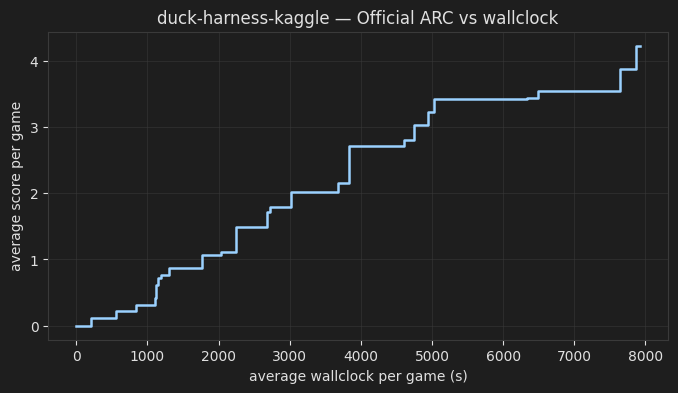
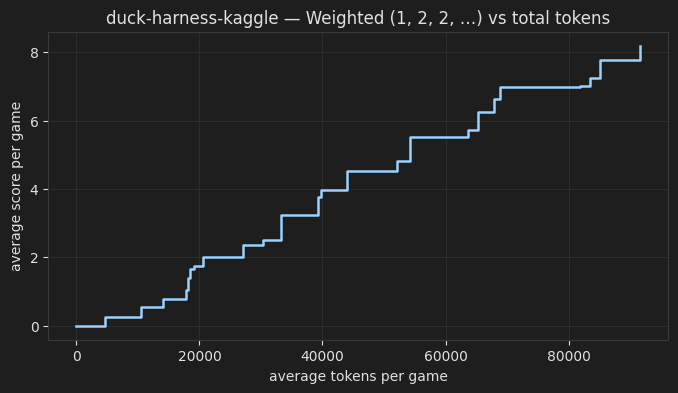
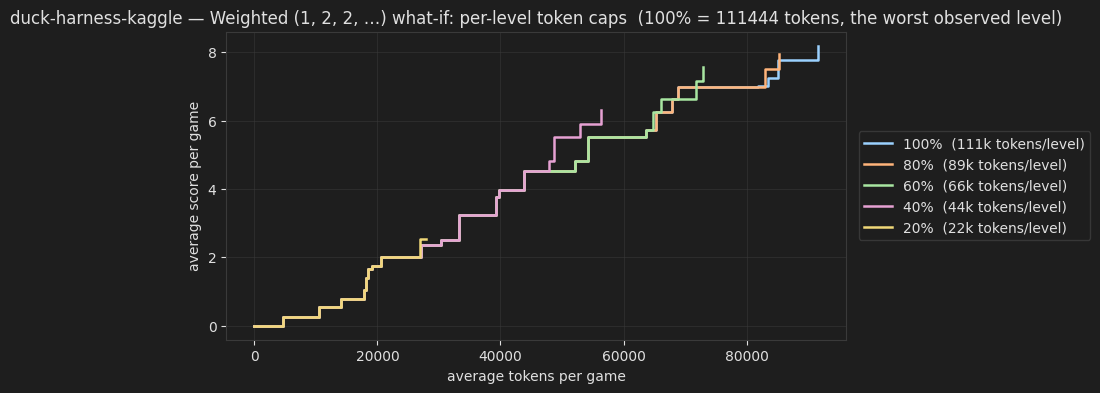
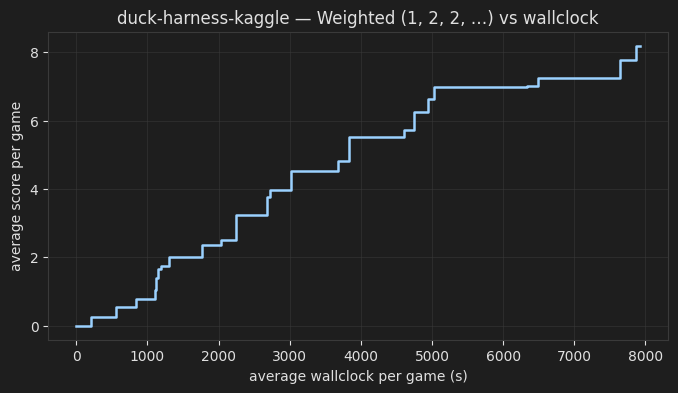
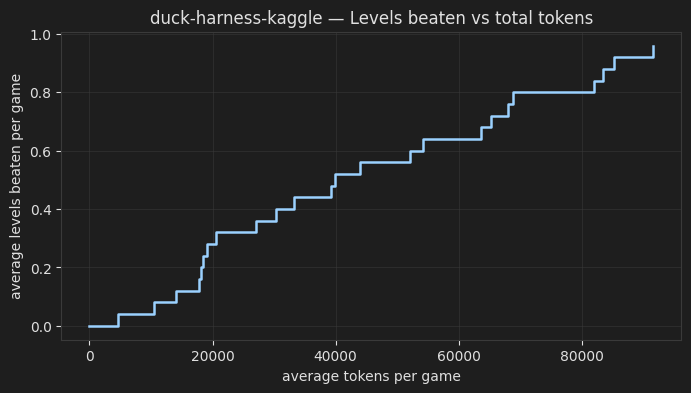
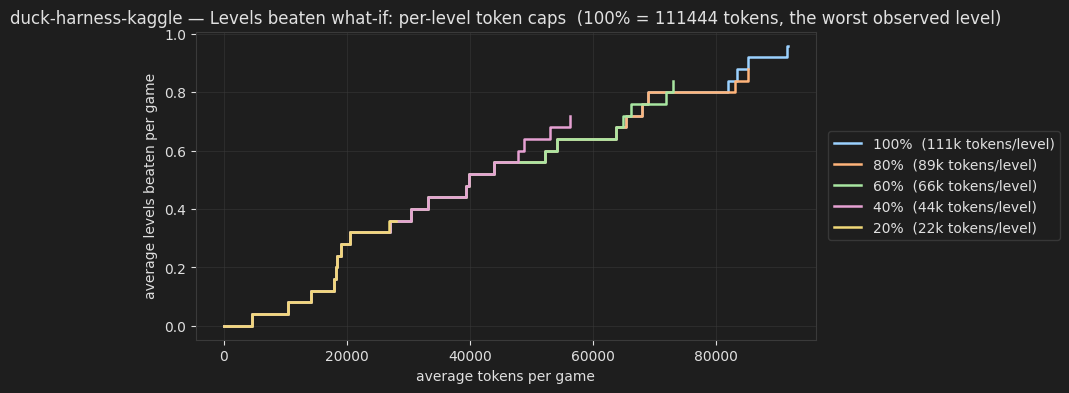
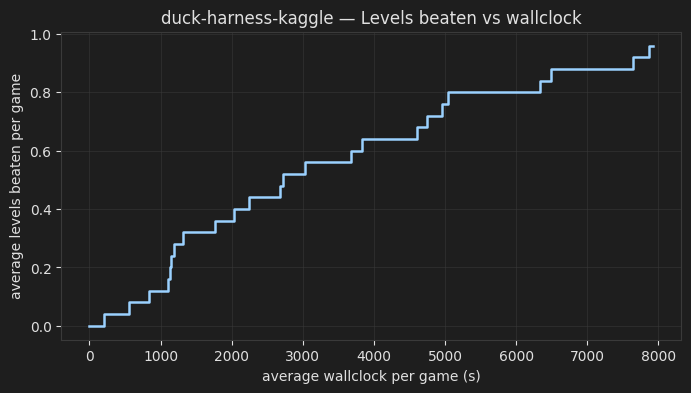
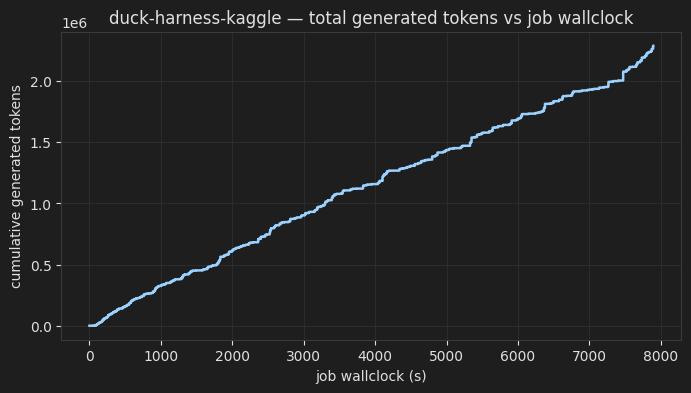
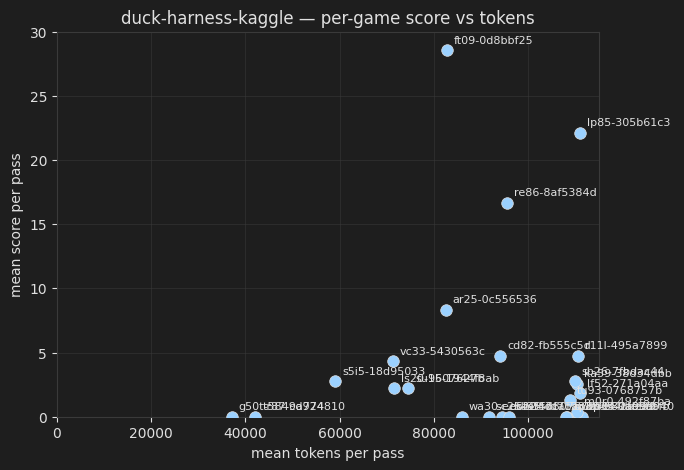
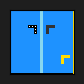
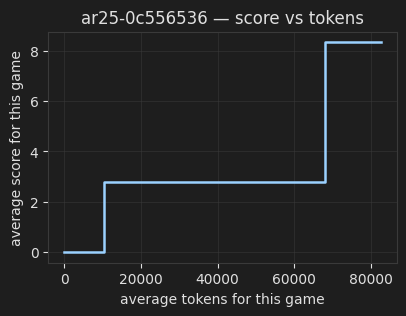
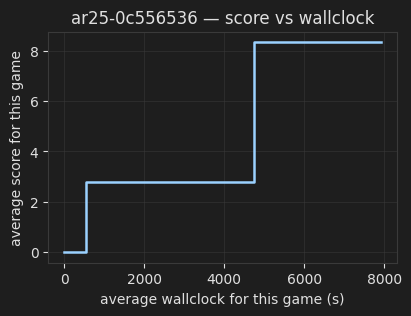
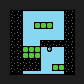
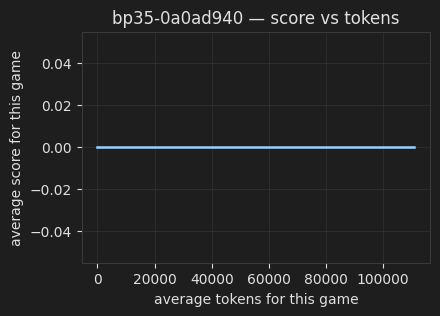
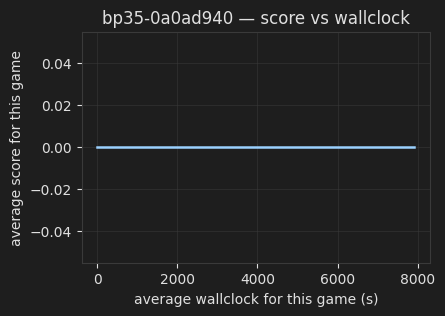
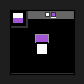
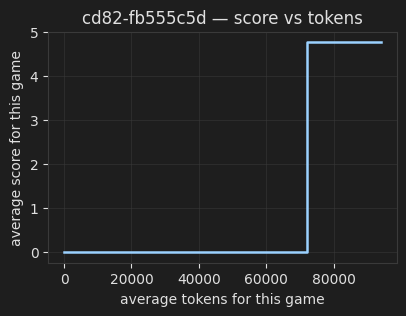
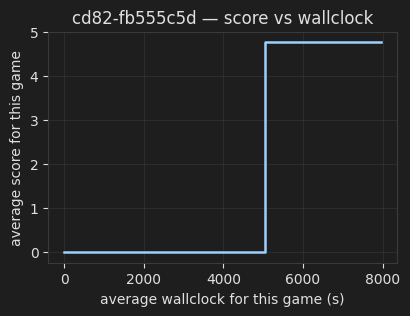
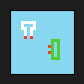
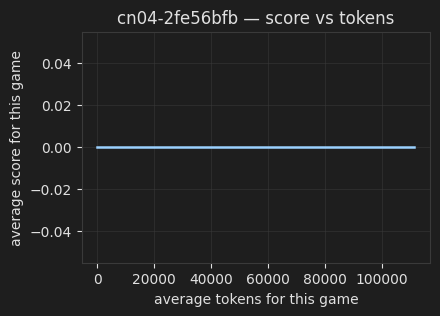
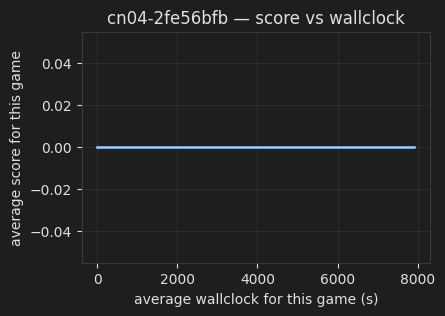
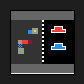
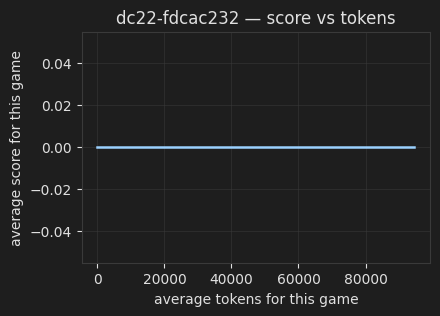
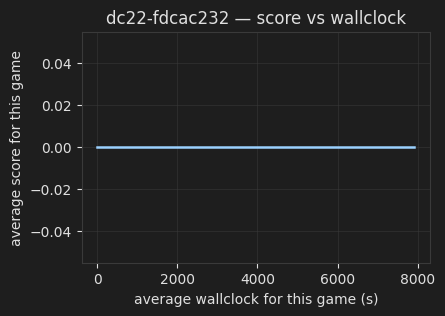
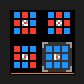
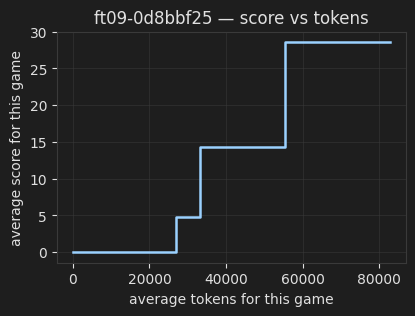
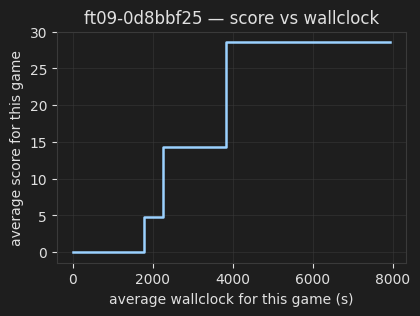
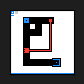
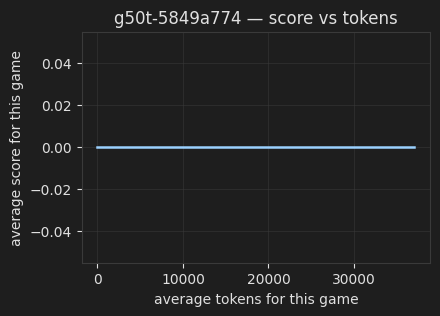
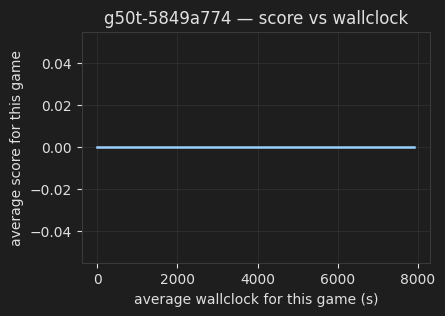
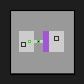
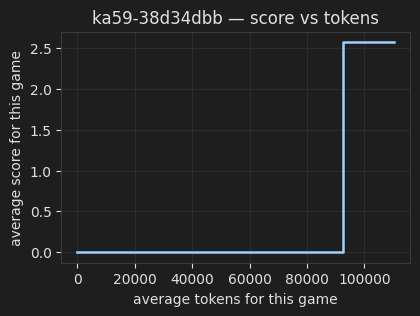
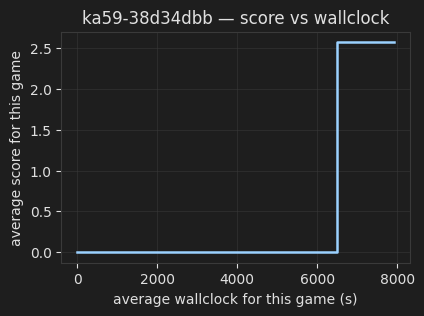
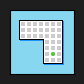
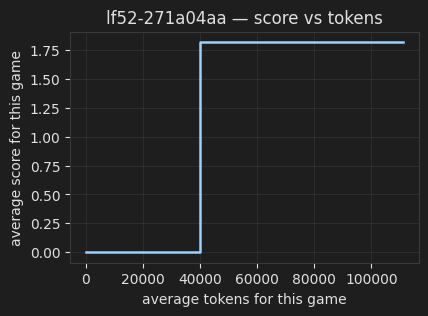
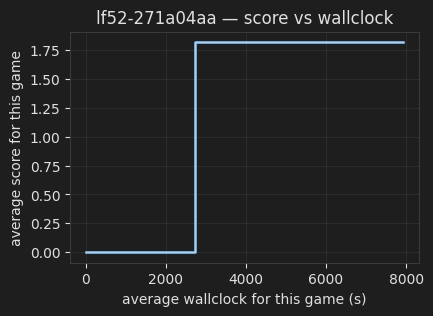
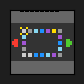
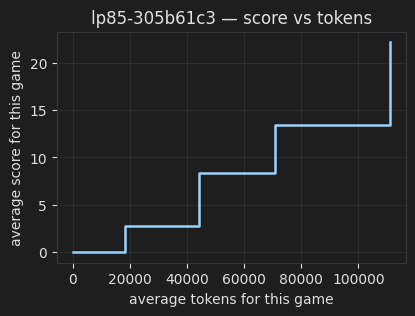
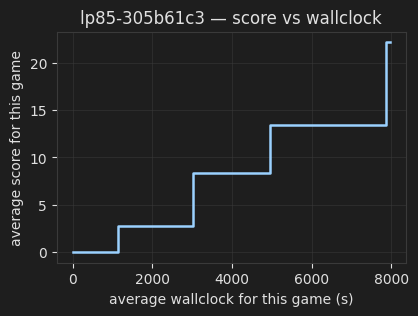
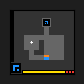
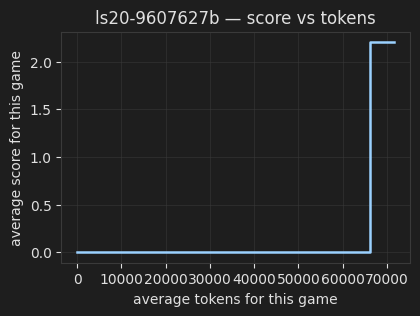
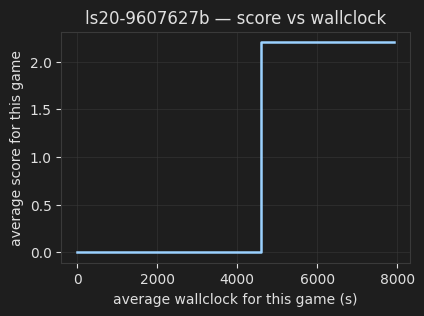
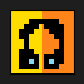
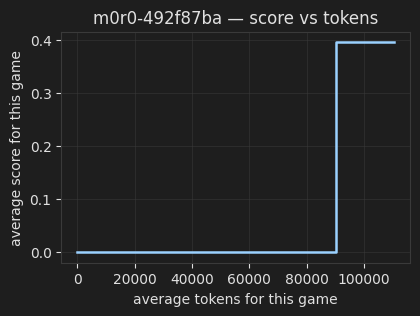
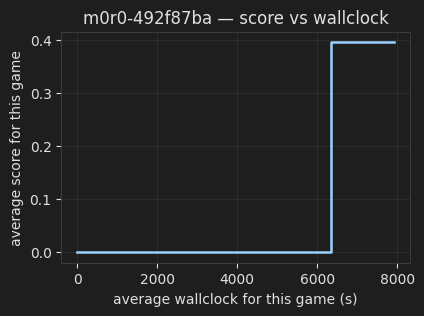
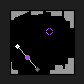
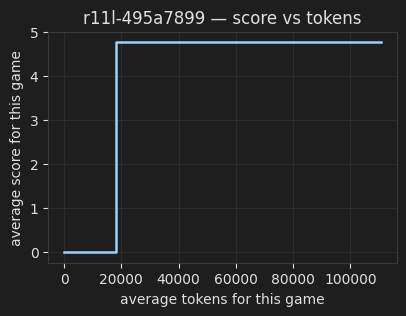
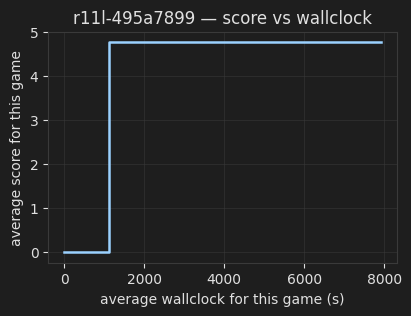
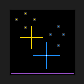
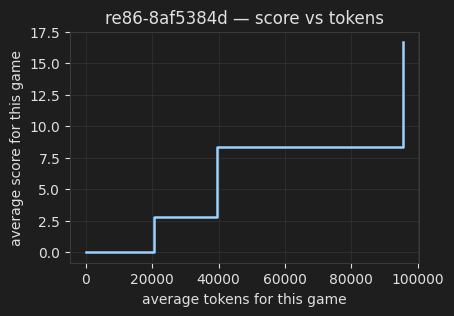
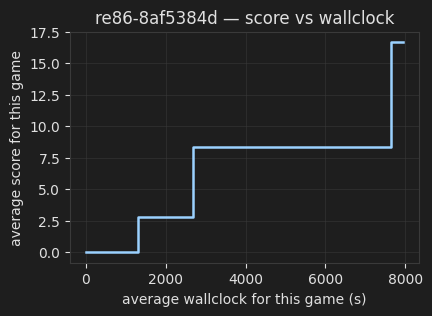
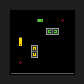
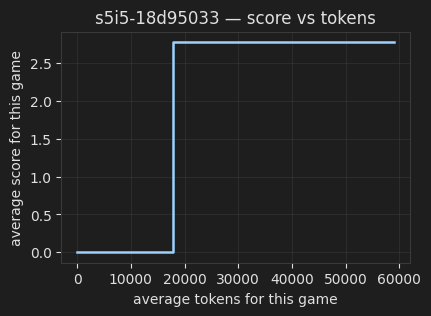
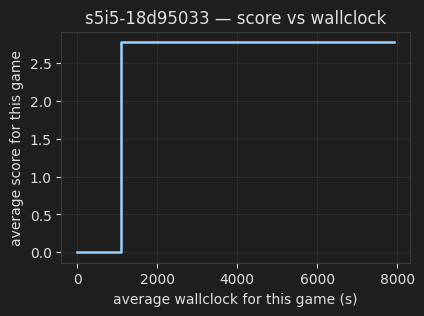
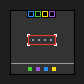
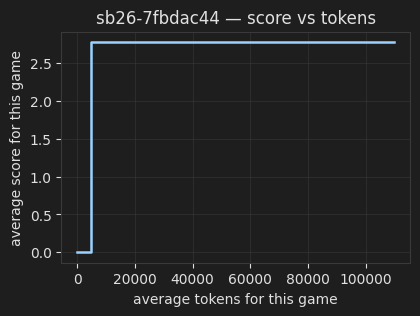
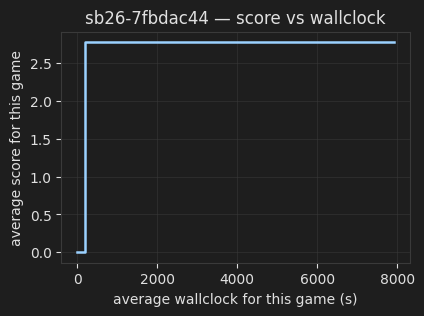
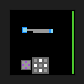
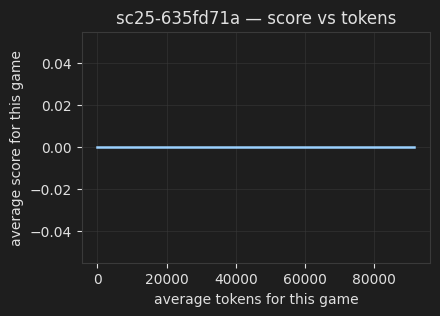
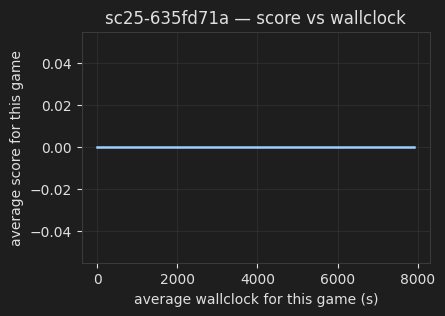
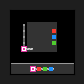
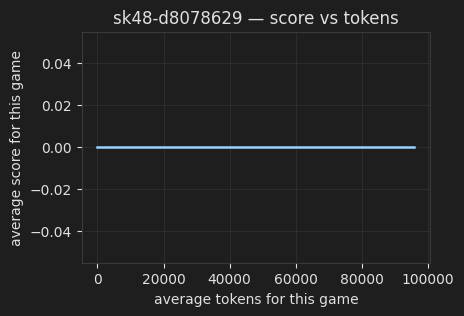
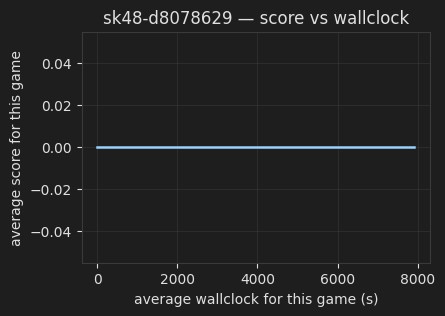
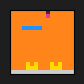
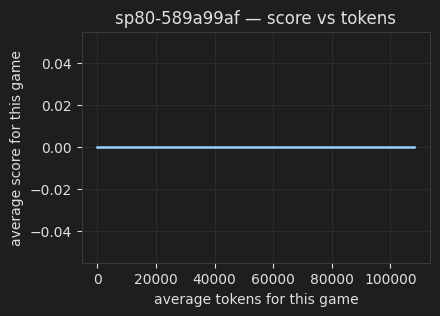
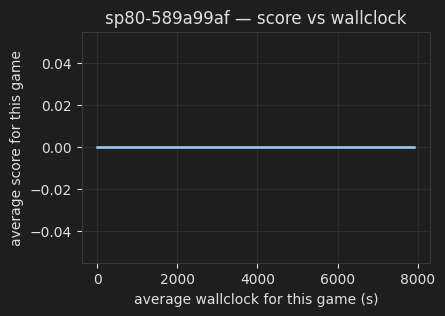
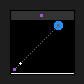
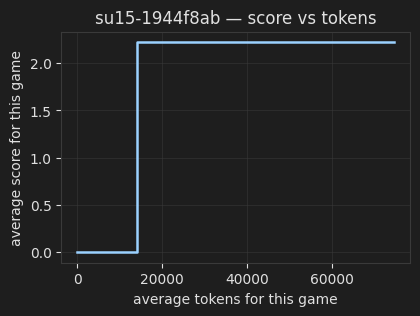
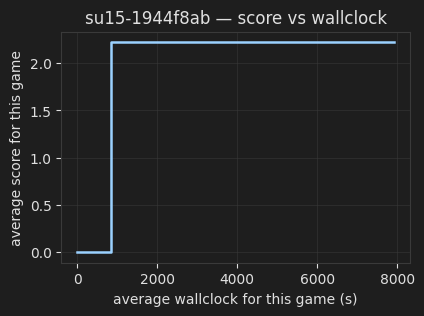
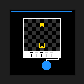
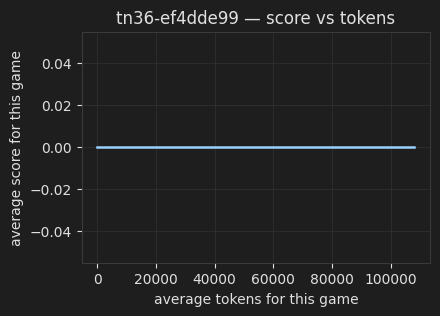
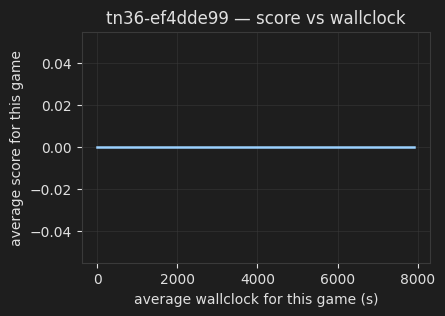
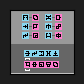
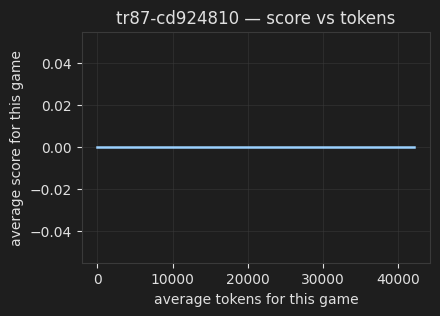
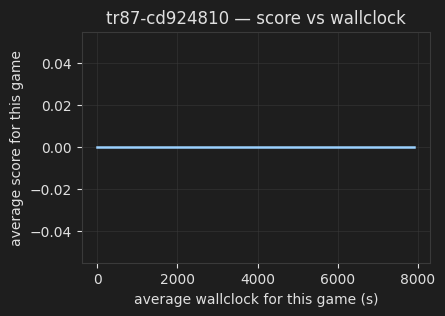
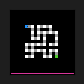
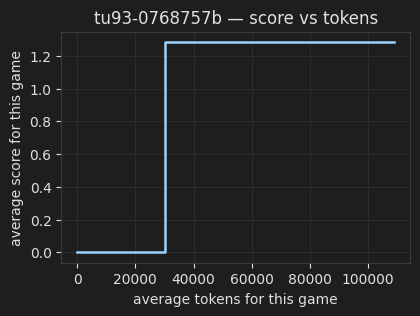
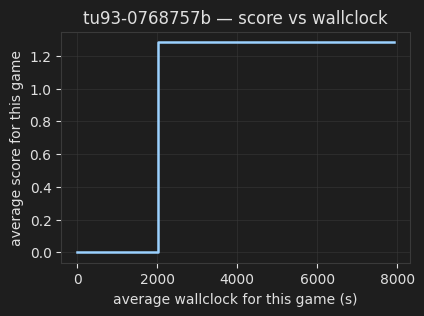
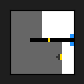
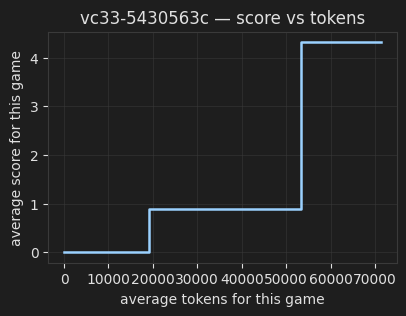
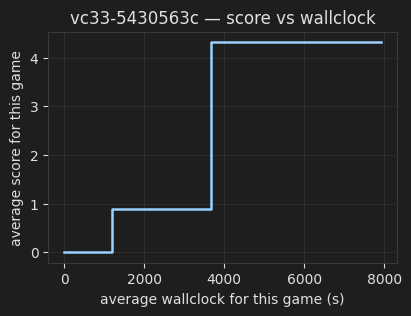
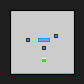
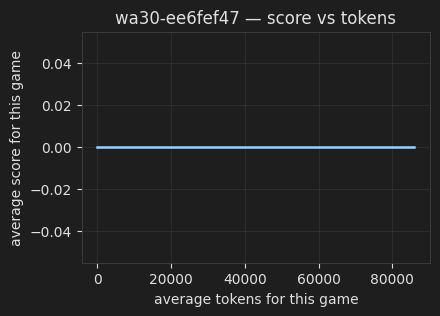
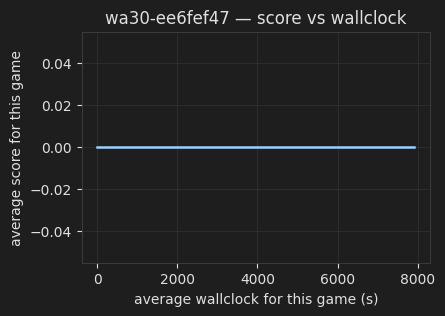
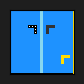
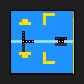
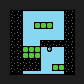
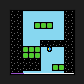
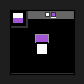
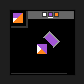
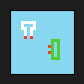
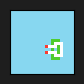
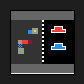
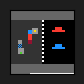
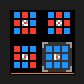
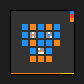
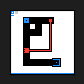
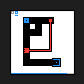
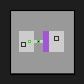
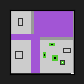
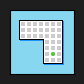
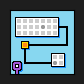
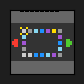
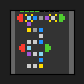
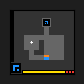
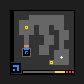
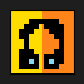
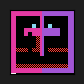
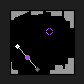
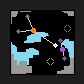
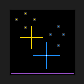
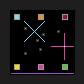
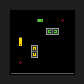
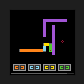
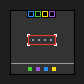
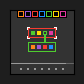
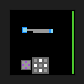
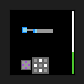
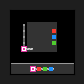
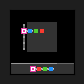
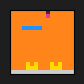
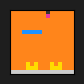
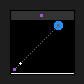
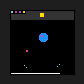
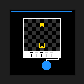
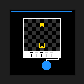
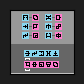
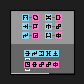
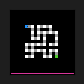
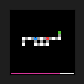
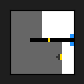
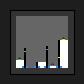
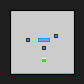
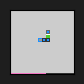

In [8]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")